In [34]:
import kagglehub
import os
import numpy
import keras
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

print(path)

train_dir = os.path.join(path, 'chest_xray', 'train')
test_dir = os.path.join(path, 'chest_xray', 'test')
val_dir = os.path.join(path, 'chest_xray', 'val')

print('Train dir:',train_dir)


Path to dataset files: /home/yahhas/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
/home/yahhas/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Train dir: /home/yahhas/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train


In [35]:
img_width, img_height = 224, 224
batch_size = 32

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size = (img_width, img_height),
    batch_size = batch_size,
    label_mode = 'binary',
    seed=123)

val_dataset = image_dataset_from_directory(
    val_dir,
    image_size = (img_width, img_height),
    batch_size = batch_size,
    label_mode = 'binary',
    seed = 123)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    seed=123)


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [36]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ]
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

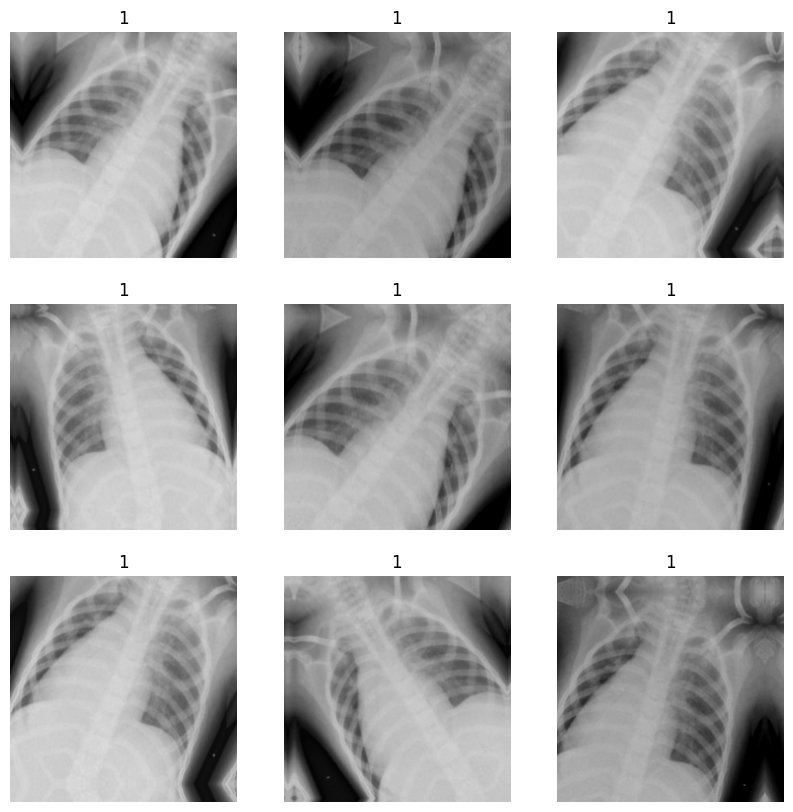

In [37]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.title(int(labels[0]))
        plt.axis("off")

In [38]:
inputs = layers.Input(shape=(img_width, img_height, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(256, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.summary()


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │        36,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,281 (1.62 MB)

 Trainable params: 425,281 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])

callbacks = [keras.callbacks.ModelCheckpoint(
    filepath = "convnet_from_scratch_with_augmentation.keras",
    save_best_only = True,
    monitor = "val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1
    )
]

history = model.fit(train_dataset, epochs=40, validation_data=val_dataset, callbacks=callbacks)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 183ms/step - accuracy: 0.7541 - loss: 0.5870 - val_accuracy: 0.5000 - val_loss: 0.7404
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - accuracy: 0.7770 - loss: 0.5049 - val_accuracy: 0.8125 - val_loss: 0.4515
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 182ms/step - accuracy: 0.8588 - loss: 0.3437 - val_accuracy: 0.8125 - val_loss: 0.3700
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.8985 - loss: 0.2403 - val_accuracy: 0.9375 - val_loss: 0.2603
Epoch 5/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.9187 - loss: 0.2064 - val_accuracy: 0.6875 - val_loss: 0.6376
Epoch 6/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.9208 - loss: 0.1930 - val_accuracy: 0.7500 - val_loss: 0.5021
Epoch 7/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.9245 - loss: 0.1847 - val_accuracy: 0.7500 - val_loss: 0.5057
Epoch 8/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 183ms/step - accuracy: 0.9153 - loss: 0

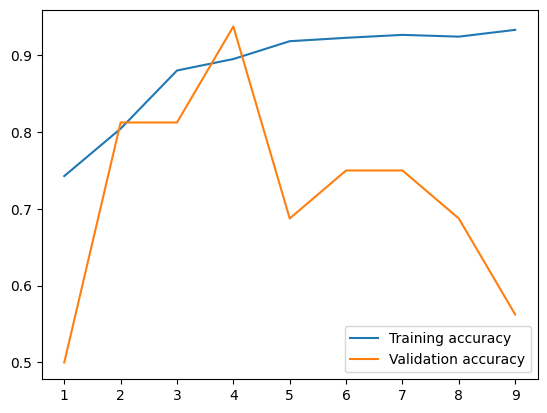

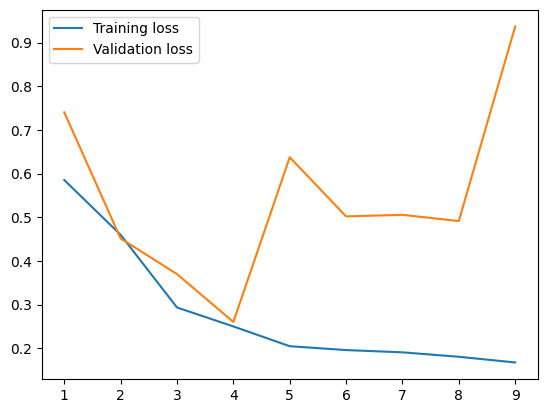

In [40]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

In [41]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8613 - loss: 0.3130
Test accuracy: 0.8477563858032227
